In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve, precision_score, recall_score
print("All sklearn libraries imported successfully!")

All sklearn libraries imported successfully!


In [12]:
df=pd.read_csv("C:/Users/MEGHLA/Downloads/unzip/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Text(0.5, 1.0, 'Customer Churn Distribution')

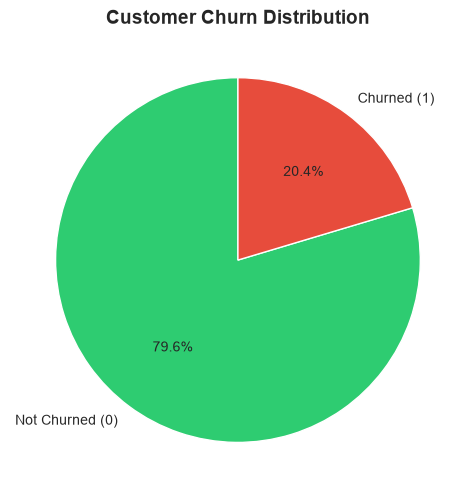

In [14]:
sns.set_style("whitegrid")
plt.figure(figsize=(20, 15))
plt.subplot(2, 3, 1)
churn_counts = df['Exited'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.pie(churn_counts, labels=['Not Churned (0)', 'Churned (1)'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')

In [18]:
df_processed = df.copy()
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_processed = df_processed.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")
print(f"Remaining columns: {df_processed.columns.tolist()}")

Dropped columns: ['RowNumber', 'CustomerId', 'Surname']
Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [20]:
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features: {X.columns.tolist()}")
print(f"Target distribution:\n{y.value_counts()}")


Features shape: (10000, 10)
Target shape: (10000,)
Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [35]:
#Encode the categorical columns in df_processed
le_geography = LabelEncoder()
df_processed['Geography'] = le_geography.fit_transform(df_processed['Geography'])

le_gender = LabelEncoder()
df_processed['Gender'] = le_gender.fit_transform(df_processed['Gender'])

X = df_processed[['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']]
y = df_processed['Exited']

# 3. Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Now works perfectly!
X_test_scaled = scaler.transform(X_test)


In [39]:
models = {'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)}

# Dictionary to store results
results = {}
# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}\n")

Training Logistic Regression...
Logistic Regression - Accuracy: 0.7065, Precision: 0.3675, Recall: 0.6845, F1-Score: 0.4782

Training Random Forest...
Random Forest - Accuracy: 0.8475, Precision: 0.6122, Recall: 0.6107, F1-Score: 0.6115

